In [1]:
import numpy as np
import matplotlib.pyplot as plt
import bionetgen
import roadrunner

# Load model from BNGL
#infile="mapk3_inh.bngl"
# NOTE: If you change the input file you may need to change simulation and output settings below
infile="fceri_starter.bngl"
model = bionetgen.bngmodel(infile) 
sim = model.setup_simulator() # sim is a libroadrunner simulator object

## Run a single simulation and plot the results

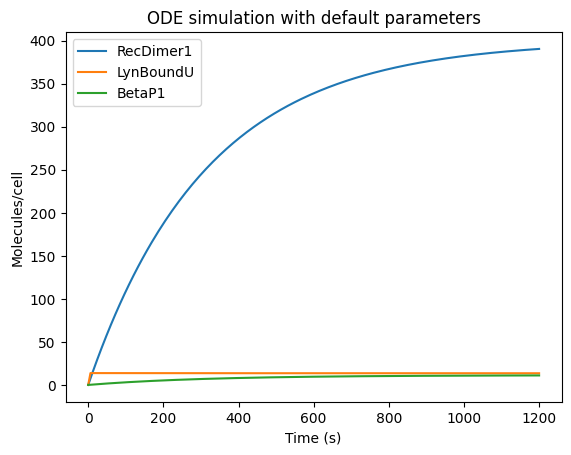

In [2]:
# Simulate using RoadRunner defaults (ODEs)
onames= [ o for o in model.observables]
sel = ['Time'] + onames
sim['Lyn_tot']=28
sim.reset()
res1= sim.simulate(0,1200,200,selections=sel)

# Plot observables
onames=['RecDimer1','LynBoundU','BetaP1']
for o in onames:
    plt.plot(res1['time'],res1[o],label=o)
#    plt.plot(res1['time'],res1[o]/res1[o][-1],label=o)
plt.title("ODE simulation with default parameters")
plt.xlabel("Time (s)")
plt.ylabel("Molecules/cell")
_= plt.legend()

## Compare results of two or more simulations

Varying parameter Lig_tot, original value=6000.0


Text(0, 0.5, 'Molecules/cell')

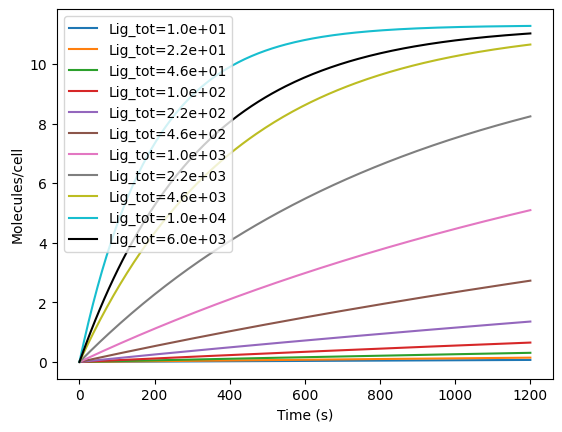

In [3]:
pname='Lig_tot'
o= 'BetaP1'
orig= sim[pname]
print(f'Varying parameter {pname}, original value={orig}')
for val in np.logspace(1,4,10): 
    sim[pname]=val
    sim.reset() 
    res2= sim.simulate(0,1200,200,selections=sel)
    plt.plot(res2['time'],res2[o],label=f'{pname}={val:0.1e}')
plt.plot(res1['time'],res1[o],'k', label=f'{pname}={orig:0.1e}')
plt.legend(loc='best')
plt.xlabel("Time (s)")
plt.ylabel("Molecules/cell")


## Scan the initial concentration of ligand and plot steady state value

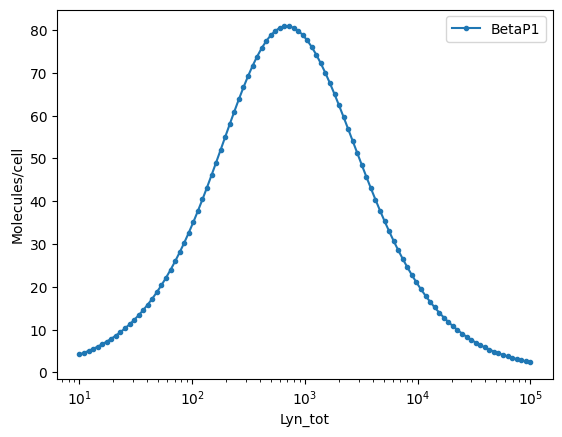

In [80]:
pname='Lyn_tot'
o='BetaP1'
out=[]
krange= np.logspace(1,5,100)
for k in krange: 
    sim[pname]=k
    # Must reset simulator AFTER changing initial condition.
    sim.reset() 
    res2= sim.simulate(0,10000,200,selections=sel)
    res= res2[o][-1]
    #print(k,res)
    out.append(res)
plt.semilogx(krange,out,'.-',label=o)
plt.xlabel(pname)
plt.ylabel("Molecules/cell")
plt.legend(loc='best')
#plt.title(f'Steady state {o} vs {pname}')

# Local Sensitivity Analysis

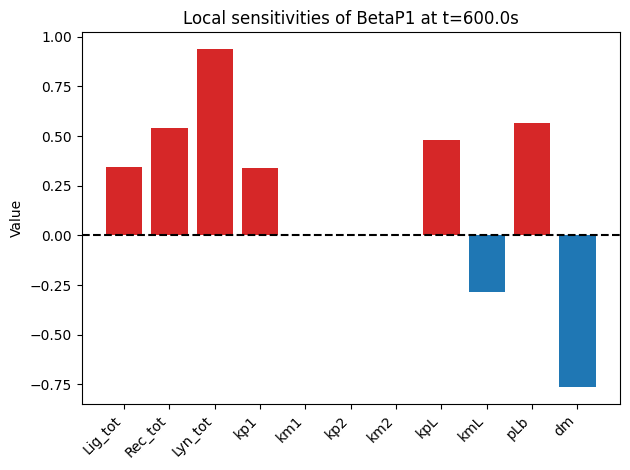

In [81]:
pnames= [p for p in model.parameters]
# Drop parameters starting with '_' from pnames
pnames= [p for p in pnames if not p.startswith('_')]
#pnames=['Lyn_tot','kp1','kp2','kpL','kmL','pLb','dm']
obs='BetaP1'
t_end=600; n_steps=200
x=1e-4
#print(pnames)

# Compute nominal trajectory
sim.resetAll()
res_nom= sim.simulate(0,t_end,n_steps,selections=sel)
#plt.plot(res_nom['time'],res_nom[obs],label=obs)
O_nom= res_nom[obs][1:] # Value of obs at each point on trajectory
S= {}
# Compute perturbed trajectories for each parameter of interest
for p in pnames:
    orig= sim[p]
    sim[p]= (1+x)*sim[p] # set p to perturbed value
    sim.reset()
    res=sim.simulate(0,t_end,n_steps,selections=sel)
    O_curr= res[obs][1:]
    S[p]=(((O_curr-O_nom)/O_nom)/x)
    sim[p]= orig  # reset parameter value

# Bar chart of sensitivities at final time point
final_time= res_nom['time'][-1]
svals= [ S[p][-1] for p in pnames]
# color bars based on sign of sensitivity
colors= ['tab:blue' if s<0 else 'tab:red' for s in svals]
plt.bar(pnames,svals,color=colors)
plt.xticks(rotation=45,ha='right')
plt.ylabel(f'Value')
plt.title(f'Local sensitivities of {obs} at t={final_time:.1f}s')
# Dashed line at y=0
plt.axhline(0,ls='--',color='k')
plt.tight_layout()

In [82]:
from scipy.stats import qmc
from sklearn.linear_model import LinearRegression

# Select parameters to vary
pnames = [p for p in model.parameters if not p.startswith('_')]
n_params = len(pnames)
OOM=1

# Define log-space bounds for parameters (vary ±2 orders of magnitude)
log_bounds_lower = []
log_bounds_upper = []
nominal_values = []

for p in pnames:
    nominal = sim[p]
    nominal_values.append(nominal)
    if nominal > 0:
        log_bounds_lower.append(np.log10(nominal) - OOM)  # 100x lower
        log_bounds_upper.append(np.log10(nominal) + OOM)  # 100x higher
    else:
        # For parameters that are 0, use a small range
        log_bounds_lower.append(-6)
        log_bounds_upper.append(-2)

log_bounds_lower = np.array(log_bounds_lower)
log_bounds_upper = np.array(log_bounds_upper)

print(f"Sampling {n_params} parameters using Latin Hypercube")
print(f"Parameters: {pnames}")

# Generate Latin Hypercube samples in [0,1]^n_params
n_samples = 1000
sampler = qmc.LatinHypercube(d=n_params, seed=42)
unit_samples = sampler.random(n=n_samples)

# Scale to log-space bounds
log_samples = qmc.scale(unit_samples, l_bounds=log_bounds_lower, u_bounds=log_bounds_upper)

# Convert from log space to linear space
param_samples = 10**log_samples

print(f"Generated {n_samples} samples")
print(f"Sample quality (discrepancy): {qmc.discrepancy(unit_samples):.4f}")

Sampling 11 parameters using Latin Hypercube
Parameters: ['Lig_tot', 'Rec_tot', 'Lyn_tot', 'kp1', 'km1', 'kp2', 'km2', 'kpL', 'kmL', 'pLb', 'dm']
Generated 1000 samples
Sample quality (discrepancy): 0.0050


Running simulations...
  Completed 20/1000 simulations (0 failed so far)
  Completed 40/1000 simulations (0 failed so far)
  Completed 60/1000 simulations (0 failed so far)
  Completed 80/1000 simulations (0 failed so far)
  Completed 100/1000 simulations (0 failed so far)
  Completed 120/1000 simulations (0 failed so far)
  Completed 140/1000 simulations (0 failed so far)
  Completed 160/1000 simulations (0 failed so far)
  Completed 180/1000 simulations (0 failed so far)
  Completed 200/1000 simulations (0 failed so far)
  Completed 220/1000 simulations (0 failed so far)
  Completed 240/1000 simulations (0 failed so far)
  Completed 260/1000 simulations (0 failed so far)
  Completed 280/1000 simulations (0 failed so far)
  Completed 300/1000 simulations (0 failed so far)
  Completed 320/1000 simulations (0 failed so far)
  Completed 340/1000 simulations (0 failed so far)
  Completed 360/1000 simulations (0 failed so far)
  Completed 380/1000 simulations (0 failed so far)
  Completed 

/var/folders/tg/bhsjlfgx1wq0l_x5sqgjgjz80000gn/T/ipykernel_91663/3275685694.py:101: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(pnames, rotation=45, ha='right')


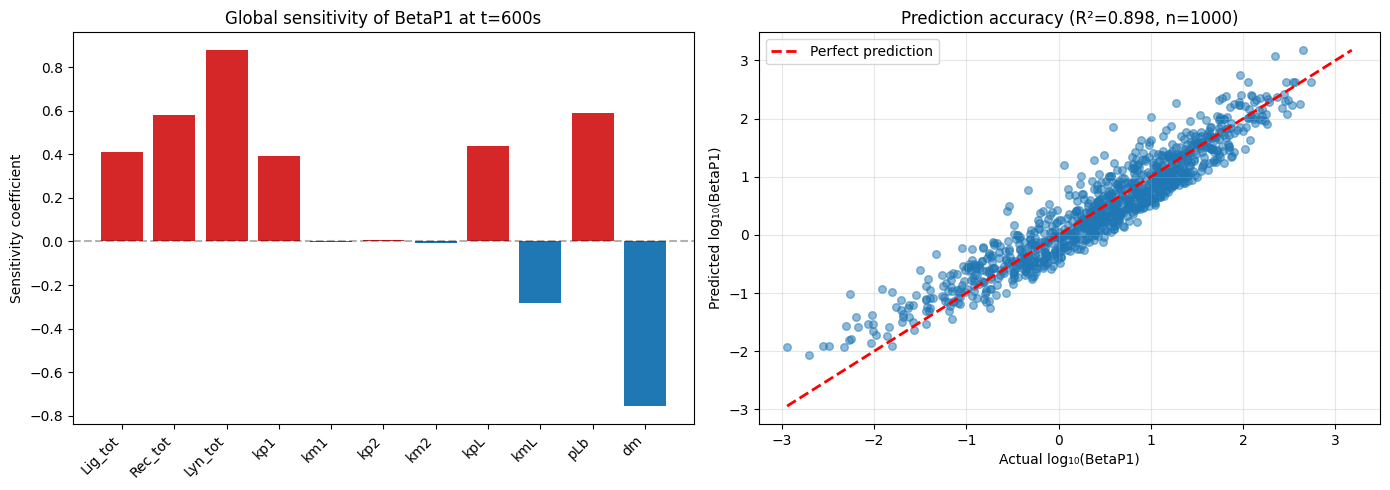

In [83]:
# Run simulations for each parameter set
import warnings
from IPython.utils.capture import capture_output

obs = 'BetaP1'  # Observable of interest
t_end = 600
n_steps = 200

outputs = []  # Store final value of observable for each sample
failed_indices = []  # Track which simulations failed

# Try to configure integrator to be more tolerant
try:
    sim.integrator.setValue('maximum_num_steps', 20000)
    sim.integrator.setValue('absolute_tolerance', 1e-12)
    sim.integrator.setValue('relative_tolerance', 1e-9)
except:
    pass  # If these settings don't work, continue anyway

print("Running simulations...")
for i, params in enumerate(param_samples):
    try:
        # Set parameter values
        for j, pname in enumerate(pnames):
            sim[pname] = params[j]

        # Reset and simulate with output capturing
        sim.reset()
        
        # Capture all output (including C-level stderr from CVODE)
        with capture_output() as captured:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                res = sim.simulate(0, t_end, n_steps, selections=sel)

        # Store final value of observable
        output_val = res[obs][-1]

        # Check for NaN or infinite values
        if np.isnan(output_val) or np.isinf(output_val):
            outputs.append(np.nan)
            failed_indices.append(i)
        else:
            outputs.append(output_val)

    except Exception as e:
        # Catch CVODE errors or any other simulation failures
        outputs.append(np.nan)
        failed_indices.append(i)
        if len(failed_indices) <= 5:  # Only print first few errors
            print(f"  Simulation {i} failed: {type(e).__name__}")

    if (i+1) % 20 == 0:
        print(f"  Completed {i+1}/{n_samples} simulations ({len(failed_indices)} failed so far)")

outputs = np.array(outputs)

# Report statistics
n_failed = len(failed_indices)
n_success = n_samples - n_failed
print(f"\nSimulation complete!")
print(f"  Successful: {n_success}/{n_samples} ({100*n_success/n_samples:.1f}%)")
print(f"  Failed: {n_failed}/{n_samples} ({100*n_failed/n_samples:.1f}%)")
if n_failed > 0:
    print(f"  Failed indices: {failed_indices[:10]}{'...' if n_failed > 10 else ''}")

# Filter out failed simulations for analysis
valid_mask = ~np.isnan(outputs)
valid_outputs = outputs[valid_mask]
valid_log_samples = log_samples[valid_mask]

print(f"\nOutput range (valid simulations): [{valid_outputs.min():.2e}, {valid_outputs.max():.2e}]")

# Perform linear regression in log space (only on successful simulations)
# X = log(parameters), y = log(output)
X_log = valid_log_samples
y_log = np.log10(valid_outputs + 1e-10)  # Add small value to avoid log(0)

# Fit linear regression model
reg = LinearRegression()
reg.fit(X_log, y_log)

# Get sensitivity coefficients (regression coefficients)
sensitivity_coeffs = reg.coef_
r2_score = reg.score(X_log, y_log)

# Get predictions
y_pred = reg.predict(X_log)

print(f"\nR² score: {r2_score:.4f}")
print(f"\nSensitivity coefficients (linear regression in log space):")
for pname, coeff in zip(pnames, sensitivity_coeffs):
    print(f"  {pname:12s}: {coeff:+.4f}")

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left plot: Sensitivity coefficients
colors = ['tab:blue' if c < 0 else 'tab:red' for c in sensitivity_coeffs]
ax1.bar(pnames, sensitivity_coeffs, color=colors)
ax1.set_xticklabels(pnames, rotation=45, ha='right')
ax1.set_ylabel('Sensitivity coefficient')
ax1.set_title(f'Global sensitivity of {obs} at t={t_end}s')
ax1.axhline(0, ls='--', color='k', alpha=0.3)

# Right plot: Predicted vs Actual
ax2.scatter(y_log, y_pred, alpha=0.5, s=30)
# Add diagonal line for perfect prediction
min_val = min(y_log.min(), y_pred.min())
max_val = max(y_log.max(), y_pred.max())
ax2.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')
ax2.set_xlabel(f'Actual log₁₀({obs})')
ax2.set_ylabel(f'Predicted log₁₀({obs})')
ax2.set_title(f'Prediction accuracy (R²={r2_score:.3f}, n={n_success})')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()